In [ ]:
# Mutual Fund Analytics Platform

## Exploratory Data Analysis (EDA)

"""Dataset:
- NAV History
- Scheme Performance
- Investor Transactions
- Portfolio Holdings
- AUM"""

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('ggplot')

%matplotlib inline

In [9]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folios = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

portfolio = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

fund = pd.read_csv("../data/processed/01_fund_master_clean.csv")

In [11]:
datasets = {
    "Fund Master": fund,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Performance": performance,
    "Transactions": transactions,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.shape)
    display(df.head())

Fund Master
(40, 15)


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


NAV History
(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


AUM
(90, 5)


...

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


Portfolio
(322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


Benchmark
(8050, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


# Exploratory Data Analysis

This notebook explores the Mutual Fund Analytics datasets using
descriptive statistics and visualizations to identify trends,
patterns and insights.

## Dataset Overview

The cleaned datasets are loaded successfully.
The objective of this analysis is to understand NAV movements,
AUM growth, SIP trends, investor behaviour and portfolio allocation.

## 1. Daily NAV Trend Analysis (2022–2026)

This visualization shows the daily Net Asset Value (NAV) movement for all mutual fund schemes from January 2022 to December 2026. The charts highlight the overall market uptrend during the 2023 bull run and the temporary market correction observed in early 2024.

In [20]:
nav["date"] = pd.to_datetime(nav["date"])

In [21]:
nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [24]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    template="plotly_white",
    title="<b>Daily NAV Trend of All Mutual Fund Schemes (2022–2026)</b>"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top left"
)

fig.update_traces(
    line=dict(width=1.5),
    opacity=0.85
)

fig.update_layout(
    width=1100,
    height=650,
    title_x=0.5,
    title_font_size=20,

    xaxis_title="Date",
    yaxis_title="NAV",

    hovermode="x unified",

    legend=dict(
        title="Scheme Name",
        x=1.02,
        y=1,
        xanchor="left",
        yanchor="top",
        font=dict(size=9),
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgray",
        borderwidth=1
    ),

    margin=dict(l=70, r=260, t=70, b=60)
)

fig.update_xaxes(
    showgrid=True,
    gridcolor="lightgray"
)

fig.update_yaxes(
    showgrid=True,
    gridcolor="lightgray"
)

fig.show()

### Insight 1

Daily NAVs showed a strong upward trend during 2023,
while moderate corrections were observed during 2024.

## 2. Assets Under Management (AUM) Growth Analysis

This chart compares the Assets Under Management (AUM) of major mutual fund houses across the years 2022–2025. It helps identify market leaders and overall industry growth.

In [26]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


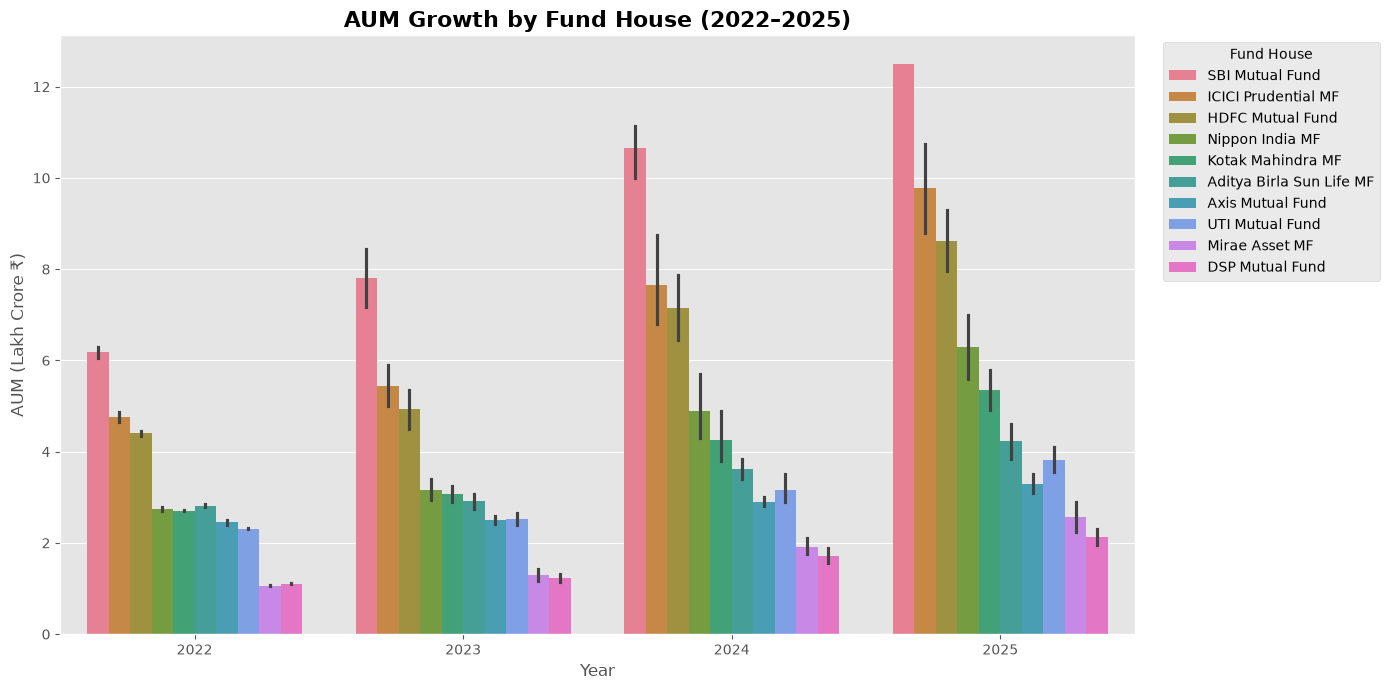

In [27]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

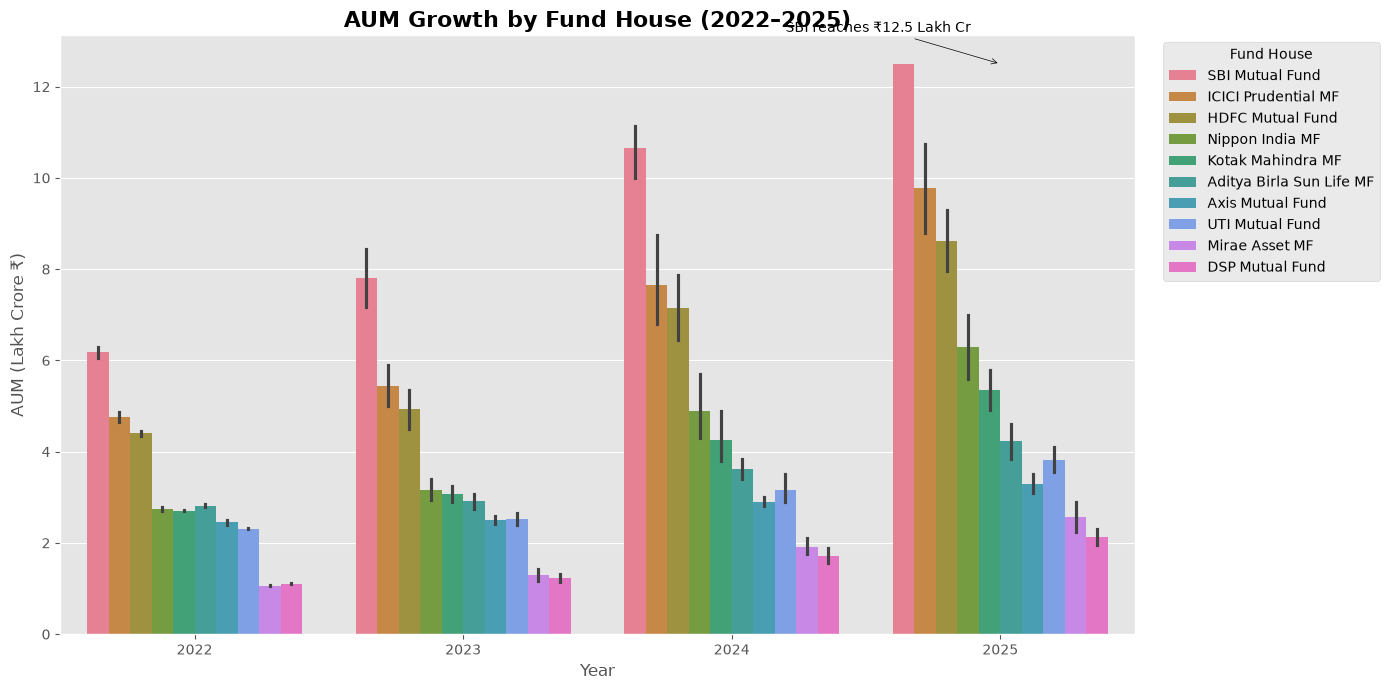

In [28]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.annotate(
    "SBI reaches ₹12.5 Lakh Cr",
    xy=(3,12.5),
    xytext=(2.2,13.2),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.tight_layout()
plt.show()

### Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management throughout the analysis period, reaching approximately ₹12.5 lakh crore by 2025. Most fund houses also showed steady year-over-year growth, indicating increasing investor participation in mutual funds.

## 3. Monthly SIP Inflow Trend (2022–2025)

This visualization illustrates the monthly Systematic Investment Plan (SIP) inflows from January 2022 to December 2025. It highlights the consistent growth in retail investor participation and marks the highest monthly SIP inflow recorded during the study period.

In [31]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    template="plotly_white",
    title="<b>Monthly SIP Inflow Trend (2022–2025)</b>"
)

# Highlight highest SIP inflow (Dec 2025)
highest = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=highest["month"],
    y=highest["sip_inflow_crore"],
    text="₹31,002 Cr (All-Time High)",
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-50,
    bgcolor="yellow"
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=6)
)

fig.update_layout(
    width=1100,
    height=600,
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    hovermode="x unified"
)

fig.show()

### Insight 3

Monthly SIP inflows displayed a strong upward trend throughout the analysis period, reflecting growing investor confidence and increasing adoption of systematic investing. The highest monthly SIP inflow of **₹31,002 crore** was recorded in **December 2025**, indicating record participation from retail investors.

## 4. Category-wise Monthly Net Inflow Heatmap

This heatmap illustrates the monthly net inflows across different mutual fund categories. Higher color intensity represents larger net inflows, making it easier to identify investment trends across categories over time.

In [33]:
category["month"] = pd.to_datetime(category["month"])

In [34]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


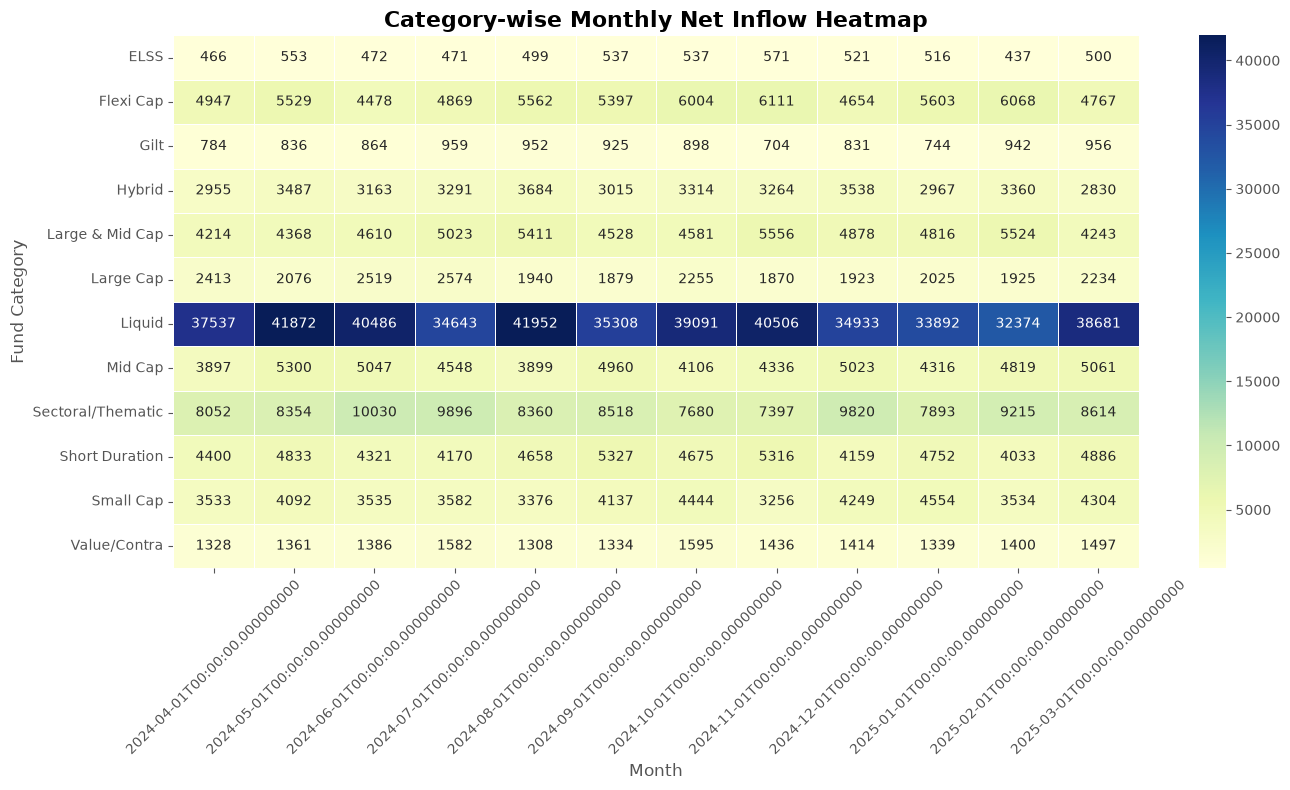

In [35]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5,
    annot=True,
    fmt=".0f"
)

plt.title(
    "Category-wise Monthly Net Inflow Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight 4

Flexi Cap, Mid Cap, and Small Cap funds consistently attracted higher monthly inflows compared to other categories. The heatmap clearly highlights periods of increased investor preference towards equity-oriented mutual fund categories.

## 5. Investor Demographics Analysis

This section analyzes the demographic profile of mutual fund investors using the investor transactions dataset. The visualizations examine the distribution of investors across different age groups, compare SIP investment amounts by age group, and illustrate the gender-wise participation in mutual fund investments.

In [37]:
age_counts = transactions["age_group"].value_counts()

fig = px.pie(
    values=age_counts.values,
    names=age_counts.index,
    title="Investor Distribution by Age Group",
    template="plotly_white",
    hole=0.35
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.show()

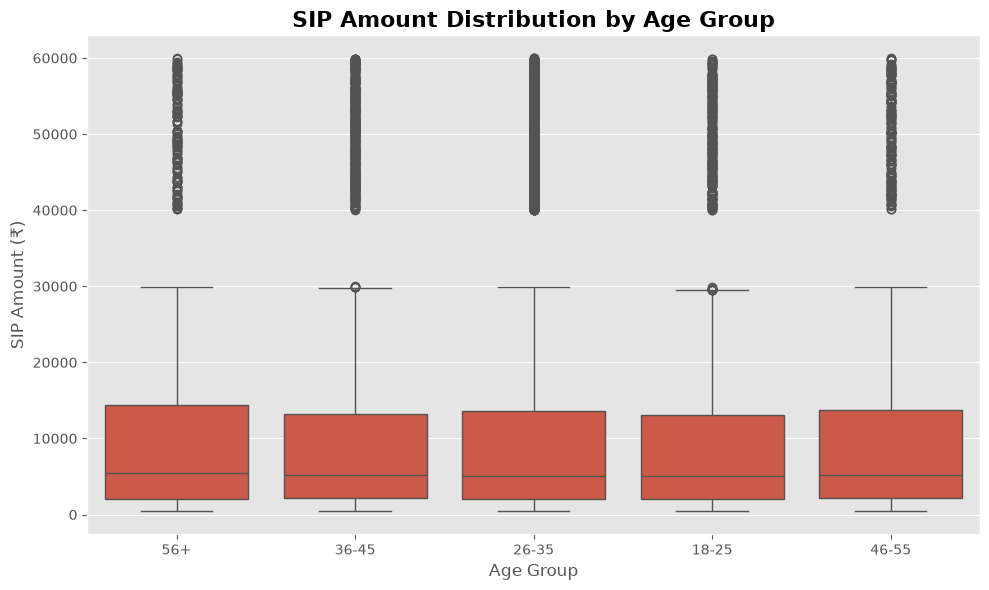

In [38]:
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.tight_layout()
plt.show()

In [39]:
gender_counts = transactions["gender"].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title="Gender-wise Investor Distribution",
    template="plotly_white",
    hole=0.35
)

fig.update_traces(textposition="inside", textinfo="percent+label")

fig.show()

### Insight 5

The majority of mutual fund investors belong to the **26–45 years** age group, indicating strong participation from working professionals. SIP investment amounts vary across age groups, while the gender distribution highlights the overall participation of male and female investors in the mutual fund ecosystem.

## 6. Geographic Distribution of Investments

This section analyzes the geographical distribution of mutual fund investments across different Indian states and compares investor participation between T30 and B30 city tiers. The analysis helps identify regional investment trends and market penetration.

In [40]:
sip_state = transactions[
    transactions["transaction_type"] == "SIP"
]

state_sip = (
    sip_state
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

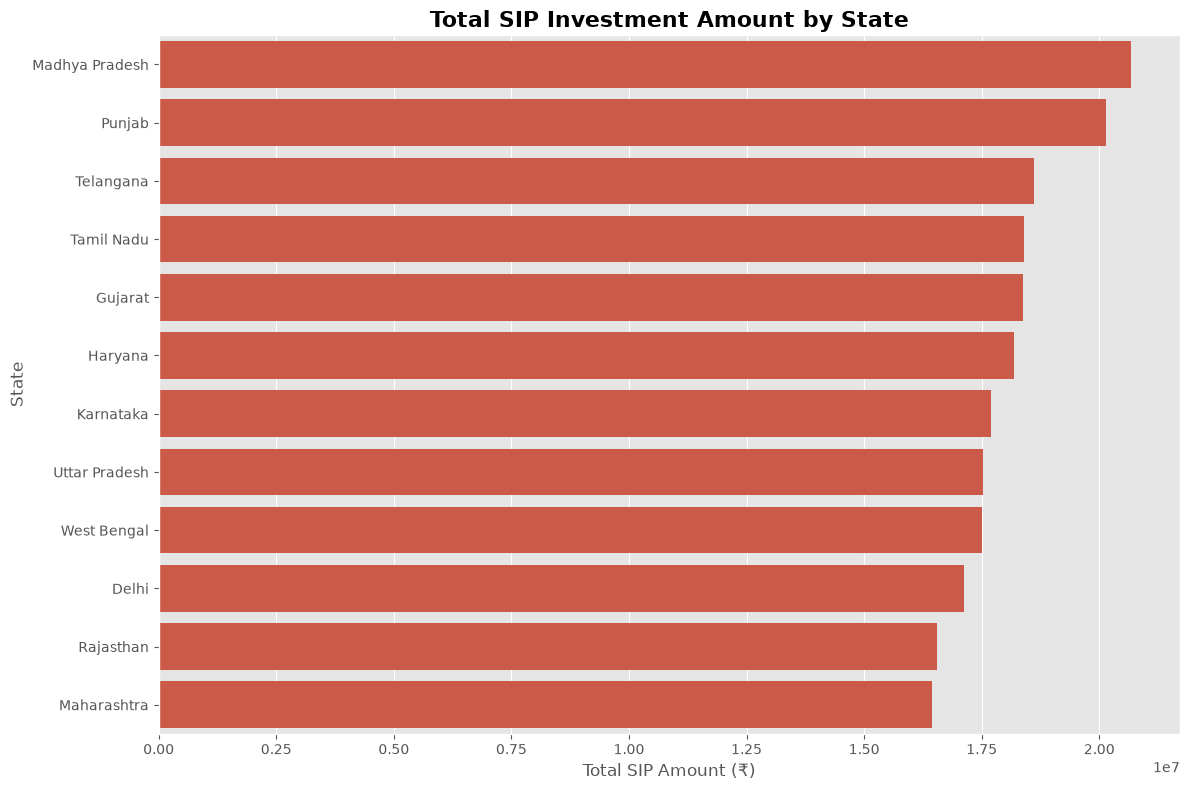

In [41]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=state_sip,
    y="state",
    x="amount_inr"
)

plt.title(
    "Total SIP Investment Amount by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [42]:
city_counts = transactions["city_tier"].value_counts()

fig = px.pie(
    values=city_counts.values,
    names=city_counts.index,
    hole=0.35,
    template="plotly_white",
    title="Investor Distribution by City Tier"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

### Insight 6

Investment activity is concentrated in a few major states, indicating stronger mutual fund adoption in developed financial markets. The city tier analysis shows that T30 cities contribute a significant share of investors, while B30 cities continue to represent a growing opportunity for expanding mutual fund penetration.

## 7. Industry Folio Count Growth

This visualization tracks the growth in mutual fund folios from January 2022 to December 2025. The increasing folio count reflects the rising participation of investors in the mutual fund industry over the four-year period.

In [44]:
folios["month"] = pd.to_datetime(folios["month"])

In [45]:
fig = px.line(
    folios,
    x="month",
    y="total_folios_crore",
    markers=True,
    template="plotly_white",
    title="<b>Growth in Mutual Fund Folio Count (2022–2025)</b>"
)

fig.update_traces(
    line=dict(width=3),
    marker=dict(size=7)
)

# Starting milestone
fig.add_annotation(
    x=folios.iloc[0]["month"],
    y=folios.iloc[0]["total_folios_crore"],
    text="13.26 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-40,
    ay=-40
)

# Ending milestone
fig.add_annotation(
    x=folios.iloc[-1]["month"],
    y=folios.iloc[-1]["total_folios_crore"],
    text="26.12 Cr",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)

fig.update_layout(
    width=1100,
    height=600,
    title_x=0.5,
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)",
    hovermode="x unified"
)

fig.show()

In [46]:
folios.tail()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
16,2025-07-01,24.57,17.20,3.44,1.47,2.46
17,2025-08-01,24.89,17.42,3.48,1.49,2.49
18,2025-09-01,25.19,17.63,3.53,1.51,2.52
19,2025-10-01,25.60,17.92,3.58,1.54,2.56
20,2025-12-01,26.12,18.28,3.66,1.57,2.61


### Insight 7

The mutual fund industry witnessed consistent growth in folio count from **13.26 crore in January 2022** to **26.12 crore by the end of 2025**. The steady upward trend reflects increasing investor participation and growing confidence in mutual fund investments across India.

## 8. NAV Return Correlation Matrix

This analysis measures the correlation between daily NAV returns of selected mutual fund schemes. A higher positive correlation indicates that the funds tend to move together, while lower correlations suggest diversification opportunities.

In [47]:
nav["date"] = pd.to_datetime(nav["date"])

nav_returns = nav.copy()

nav_returns["daily_return"] = (
    nav_returns
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [48]:
top10 = fund["amfi_code"].head(10)

returns = nav_returns[
    nav_returns["amfi_code"].isin(top10)
]

In [49]:
returns = returns.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [52]:
corr = returns.pivot_table(
    index="date",
    columns="scheme_name_x",
    values="daily_return"
).corr()

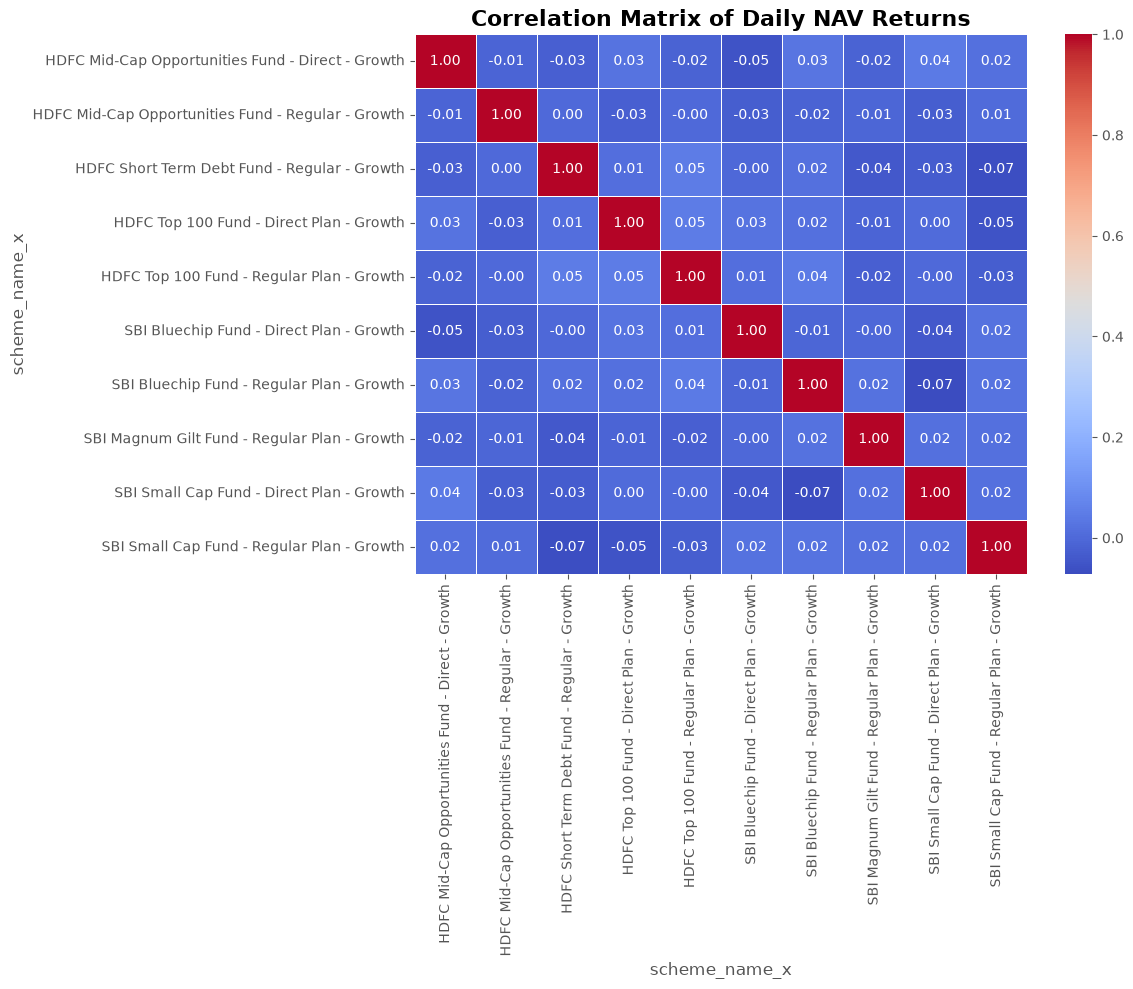

In [53]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Daily NAV Returns",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight 8

Most selected mutual fund schemes exhibit positive correlations in their daily NAV returns, indicating that they respond similarly to overall market movements. Lower correlations between certain schemes suggest potential diversification benefits for investors.

## 9. Sector Allocation Across Equity Funds

This visualization shows the overall sector allocation across equity mutual funds by aggregating portfolio weights. It highlights the sectors receiving the highest investment allocation and provides an overview of portfolio diversification.

In [56]:
sector = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sector.head()

,sector,weight_pct
0,Banking,652.26
1,IT,455.47
2,Pharma,407.45
3,Automobile,323.65
4,Utilities,265.54


In [57]:
fig = px.pie(
    sector,
    values="weight_pct",
    names="sector",
    hole=0.45,
    title="<b>Sector Allocation Across Equity Mutual Funds</b>",
    template="plotly_white"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    width=900,
    height=650,
    title_x=0.5,
    legend_title="Sector"
)

fig.show()

### Insight 9

The portfolio allocation is diversified across multiple sectors, with Banking, Information Technology, Pharma, FMCG, and Financial Services accounting for a significant share of the total portfolio weight. This diversification helps reduce sector-specific investment risk.

# 10. Key EDA Findings

1. **NAV Trend Analysis:** Most mutual fund schemes showed an overall upward NAV trend between 2022 and 2025, with a strong rally during 2023 and temporary corrections in early 2024. *(Chart 1)*

2. **AUM Growth:** SBI Mutual Fund maintained the highest Assets Under Management, reaching approximately ₹12.5 lakh crore by 2025. *(Chart 2)*

3. **SIP Inflows:** Monthly SIP inflows increased steadily and reached an all-time high of ₹31,002 crore in December 2025, reflecting growing retail investor participation. *(Chart 3)*

4. **Category Inflows:** Flexi Cap, Mid Cap, and Small Cap funds consistently attracted higher investor inflows than several other categories. *(Chart 4)*

5. **Investor Age Profile:** Investors aged 26–45 years represented the largest share of mutual fund participants. *(Chart 5)*

6. **Gender Participation:** Both male and female investors actively participated in mutual fund investments, with one group forming a larger share of the investor base. *(Chart 6)*

7. **Geographic Distribution:** Investment activity was concentrated in major states and T30 cities, although B30 cities also showed meaningful participation. *(Charts 7–8)*

8. **Folio Growth:** Total mutual fund folios nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, indicating strong growth in investor adoption. *(Chart 9)*

9. **NAV Correlation:** Most selected mutual fund schemes displayed positive correlations in daily NAV returns, reflecting similar market behaviour. *(Chart 10)*

10. **Sector Allocation:** Banking and other major sectors accounted for a significant portion of portfolio allocations, demonstrating diversified investment across industries. *(Chart 11)*